In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [ ]:
# 1. Data ban đầu
data = np.array([1, 4, 10, 20, 35, 55])
n = len(data)

plt.figure(figsize=(10,5))
plt.plot(range(1, n+1), data, marker='o')
plt.title("Dữ liệu ban đầu")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị")
plt.grid(True)
plt.show()

In [5]:
# 2. Kiểm tra stationarity bằng Augmented Dickey-Fuller test
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print("ADF Statistic: {:.4f}".format(result[0]))
    print("p-value: {:.4f}".format(result[1]))
    if result[1] < 0.05:
        print("✅ Dữ liệu stationarity.")
    else:
        print("❌ Dữ liệu không stationarity, cần sai phân.")

print("\nKiểm tra dữ liệu gốc:")
check_stationarity(data)


Kiểm tra dữ liệu gốc:
ADF Statistic: -4.8000
p-value: 0.0001
✅ Dữ liệu stationarity.


In [6]:
# 3. Sai phân bậc 1
diff1 = np.diff(data, n=1)
print("\nSai phân bậc 1:", diff1)

print("\nKiểm tra dữ liệu sau sai phân bậc 1:")
check_stationarity(diff1)


Sai phân bậc 1: [ 3  6 10 15 20]

Kiểm tra dữ liệu sau sai phân bậc 1:
ADF Statistic: 3.0000
p-value: 1.0000
❌ Dữ liệu không stationarity, cần sai phân.


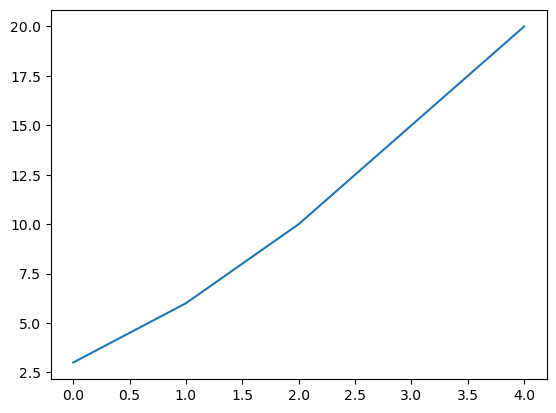

In [8]:
plt.plot(diff1)

In [9]:
# 4. Sai phân bậc 2 nếu cần
diff2 = np.diff(data, n=2)
print("\nSai phân bậc 2:", diff2)

print("\nKiểm tra dữ liệu sau sai phân bậc 2:")
check_stationarity(diff2)


Sai phân bậc 2: [3 4 5 5]

Kiểm tra dữ liệu sau sai phân bậc 2:
ADF Statistic: -1.7321
p-value: 0.4147
❌ Dữ liệu không stationarity, cần sai phân.


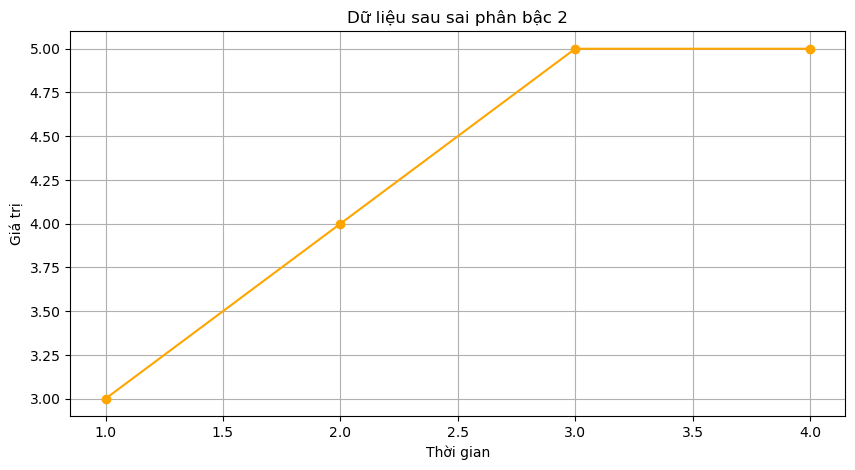

In [10]:
# 5. Vẽ dữ liệu sau differencing
plt.figure(figsize=(10,5))
plt.plot(range(1, len(diff2)+1), diff2, marker='o', color='orange')
plt.title("Dữ liệu sau sai phân bậc 2")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị")
plt.grid(True)
plt.show()

In [11]:
# 6. Fit ARIMA(p=1, d=2, q=1)
print("\nFit mô hình ARIMA(1,2,1)...")
model = sm.tsa.ARIMA(data, order=(1,2,1))
result = model.fit()

print("\nSummary của mô hình:")
print(result.summary())


Fit mô hình ARIMA(1,2,1)...

Summary của mô hình:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:                 ARIMA(1, 2, 1)   Log Likelihood                  -5.621
Date:                Sun, 27 Apr 2025   AIC                             17.242
Time:                        15:44:28   BIC                             15.401
Sample:                             0   HQIC                            13.201
                                  - 6                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9677      0.219      4.416      0.000       0.538       1.397
ma.L1          0.9863    123.455      0.008      0.994    -240.982     242.954
s

c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3160: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


In [12]:
# 7. Forecast giá trị tương lai (ví dụ dự báo 3 bước tới)
forecast = result.forecast(steps=3)
print("\nDự báo 3 bước tiếp theo:", forecast)


Dự báo 3 bước tiếp theo: [ 79.6582178  108.82410438 142.35197632]


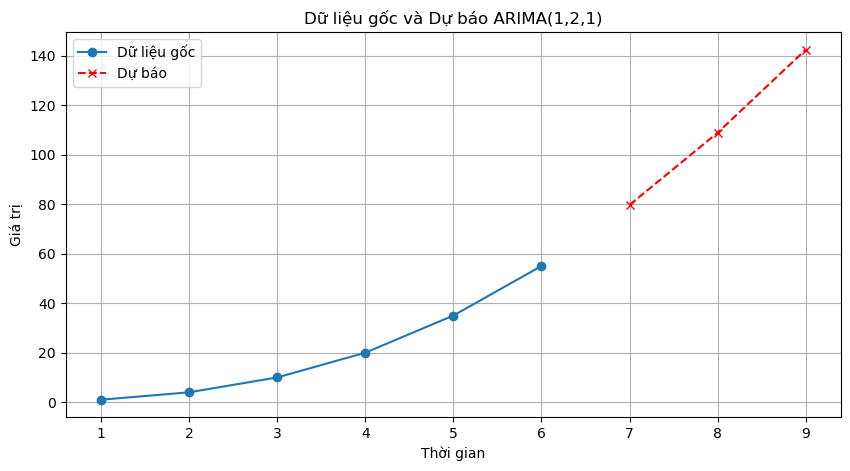

In [13]:

# 8. Vẽ biểu đồ dự báo
future_x = np.arange(n+1, n+4)
plt.figure(figsize=(10,5))
plt.plot(range(1, n+1), data, marker='o', label="Dữ liệu gốc")
plt.plot(future_x, forecast, marker='x', linestyle='--', color='red', label="Dự báo")
plt.title("Dữ liệu gốc và Dự báo ARIMA(1,2,1)")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị")
plt.legend()
plt.grid(True)
plt.show()
